# I want to repurpose the existing code for visualizing our models' performances

In [10]:
MODEL_NAME = 'baseline_rnn_beta0.1'
k = 5  # how many lowest/highest values to show

In [1]:
# wait isn't this really hard to do?
# actually I could import the trainer class like in train_model.py, and see from there...
from omegaconf import OmegaConf
from rnn_trainer import BrainToTextDecoder_Trainer

args = OmegaConf.load(f'trained_models/{MODEL_NAME}/checkpoint/args.yaml')

In [2]:
args['mode'] = 'x'
args['save_best_checkpoint'] = False
args['init_from_checkpoint'] = True
args['output_dir'] = f'trained_models/{MODEL_NAME}'
args['checkpoint_dir'] = f'trained_models/{MODEL_NAME}/checkpoint'
args['init_checkpoint_path'] = f'trained_models/{MODEL_NAME}/checkpoint/best_checkpoint'


print(args['mode'])
print(args['save_best_checkpoint'])
print(args['init_from_checkpoint'])
print(args['output_dir']) # should be trained_models/<model>
print(args['checkpoint_dir']) # should be trained_models/<model>/checkpoint
print(args['init_checkpoint_path']) # should be trained_models/<model>/checkpoint/best_checkpoint
                                    # if the next cell doesn't work, it's because best_checkpoint is still best_checkpoint.zip
                                    # rename best_checkpoint.zip to best_checkpoint in that case.

x
False
True
trained_models/baseline_rnn_beta0.1
trained_models/baseline_rnn_beta0.1/checkpoint
trained_models/baseline_rnn_beta0.1/checkpoint/best_checkpoint


In [3]:
# Construct the full absolute path
import os
relative_path = args['init_checkpoint_path']
BASE_DIR = os.getcwd()
absolute_checkpoint_path = os.path.join(BASE_DIR, relative_path)
args['init_checkpoint_path'] = absolute_checkpoint_path

trainer = BrainToTextDecoder_Trainer(args)
model = trainer.model

2025-11-27 14:05:42,095: Using device: cuda:0
2025-11-27 14:05:42,552: Using torch.compile
2025-11-27 14:05:43,897: Initialized RNN decoding model
2025-11-27 14:05:43,898: OptimizedModule(
  (_orig_mod): GRUDecoder(
    (day_layer_activation): Softsign()
    (day_weights): ParameterList(
        (0): Parameter containing: [torch.float32 of size 512x512]
        (1): Parameter containing: [torch.float32 of size 512x512]
        (2): Parameter containing: [torch.float32 of size 512x512]
        (3): Parameter containing: [torch.float32 of size 512x512]
        (4): Parameter containing: [torch.float32 of size 512x512]
        (5): Parameter containing: [torch.float32 of size 512x512]
        (6): Parameter containing: [torch.float32 of size 512x512]
        (7): Parameter containing: [torch.float32 of size 512x512]
        (8): Parameter containing: [torch.float32 of size 512x512]
        (9): Parameter containing: [torch.float32 of size 512x512]
        (10): Parameter containing: [torc

In [4]:
import h5py
import torch
import numpy as np

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# File paths
TRAIN_FILE = "../../data/hdf5_data_final/t15.2025.03.14/data_train.hdf5"
TEST_FILE = "../../data/hdf5_data_final/t15.2025.03.14/data_test.hdf5"

# --- Explore Data ---
def explore_data():
    print("Exploring training data...")
    with h5py.File(TRAIN_FILE, 'r') as f:
        trials = list(f.keys())
        print(f"Number of training trials: {len(trials)}")
        
        # Analyze sequence lengths and labels
        neural_lengths = []
        for trial_key in trials[:5]:
            trial = f[trial_key]
            neural_len = trial['input_features'].shape[0]
            label_len = trial['seq_class_ids'].shape[0]
            neural_lengths.append(neural_len)
            print(f"{trial_key}: neural={neural_len}, labels={label_len}")
            
        print(f"\nNeural length stats: min={min(neural_lengths)}, max={max(neural_lengths)}, avg={np.mean(neural_lengths):.1f}")

explore_data()

Using device: cuda
Exploring training data...
Number of training trials: 59
trial_0000: neural=950, labels=500
trial_0001: neural=932, labels=500
trial_0002: neural=939, labels=500
trial_0003: neural=701, labels=500
trial_0004: neural=513, labels=500

Neural length stats: min=513, max=950, avg=807.0


In [5]:
print(trainer.train_dataset)
print(trainer.train_loader)
print(trainer.val_dataset)
print(trainer.val_loader)

In [6]:
len(trainer.train_loader)

120000

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
def analyze_loader_batches(loader, name="Dataset", n_batches=3):
    """
    Analyze the first `n_batches` from a DataLoader.

    Note:
        - Each batch contains multiple trials.
        - This function only inspects the first `n_batches`.
        - It does NOT randomly sample trials across the whole dataset.
    """
    total_trials = 0
    total_time_steps = []
    total_seq_lens = []
    day_counts = {}

    print(f"\n{name}: analyzing first {n_batches} batches (sequential)")

    for batch_idx, batch in enumerate(loader):
        if batch_idx >= n_batches:
            break

        batch_size = batch['input_features'].shape[0]
        total_trials += batch_size

        total_time_steps.extend(batch['n_time_steps'].tolist())
        total_seq_lens.extend(batch['phone_seq_lens'].tolist())

        for d in batch['day_indicies'].tolist():
            day_counts[d] = day_counts.get(d, 0) + 1

    if total_trials == 0:
        print("No trials found in sampled batches!")
        return

    print(f"Total trials in sampled batches: {total_trials}")
    print(f"Input sequence lengths (time steps): min={min(total_time_steps)}, max={max(total_time_steps)}, mean={np.mean(total_time_steps):.2f}")
    print(f"Target sequence lengths (phonemes): min={min(total_seq_lens)}, max={max(total_seq_lens)}, mean={np.mean(total_seq_lens):.2f}")
    print(f"Days covered in sampled batches: {day_counts}")

# Analyze a few batches
analyze_loader_batches(trainer.train_loader, name="Training Dataset", n_batches=3)
analyze_loader_batches(trainer.val_loader, name="Validation Dataset", n_batches=3)


Training Dataset: analyzing first 3 batches (sequential)
Total trials in sampled batches: 192
Input sequence lengths (time steps): min=383, max=1931, mean=922.69
Target sequence lengths (phonemes): min=10, max=52, mean=27.05
Days covered in sampled batches: {3: 32, 2: 16, 30: 16, 21: 16, 8: 16, 43: 16, 16: 16, 17: 16, 13: 16, 38: 16, 12: 16}

Validation Dataset: analyzing first 3 batches (sequential)
Total trials in sampled batches: 132
Input sequence lengths (time steps): min=365, max=1203, mean=722.64
Target sequence lengths (phonemes): min=11, max=45, mean=25.86
Days covered in sampled batches: {1: 35, 2: 49, 3: 48}


In [8]:
from tqdm.notebook import tqdm

# OPTION = 1: quick validation
# ELSE: full validation
OPTION = 2

if OPTION == 1:
    n_trials_sample = 3
    val_trials = list(trainer.val_loader)[:n_trials_sample]
else:
    n_trials_sample = 41 # which matches with the YAML args, since 4 days have nothing in validation
    val_trials = list(trainer.val_loader)[:n_trials_sample]

# Run validation
metrics = trainer.validation(tqdm(val_trials), return_logits=True)

print("\n=== VALIDATION METRICS ===")
print(f"Average PER over sampled trials: {metrics['avg_PER']*100:.2f}%")
print(f"Average Loss over sampled trials: {metrics['avg_loss']:.4f}")

print("\nPER per day:")
per_list = []
for day, day_stats in metrics['day_PERs'].items():
    if day_stats['total_seq_length'] > 0:
        per = day_stats['total_edit_distance'] / day_stats['total_seq_length']
        print(f"  Day {day}: {per*100:.2f}%")
        per_list.append(per)

  0%|          | 0/41 [00:00<?, ?it/s]

W1127 14:06:15.675000 14866 site-packages/torch/_inductor/utils.py:1613] [4/0_1] Not enough SMs to use max_autotune_gemm mode
W1127 14:06:17.245000 14866 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/1] _maybe_guard_rel() was called on non-relation expression Eq(s77, 1) | Eq(s77, s59)
W1127 14:06:17.580000 14866 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/1_1] _maybe_guard_rel() was called on non-relation expression Eq(s77, 1) | Eq(s77, s59)
W1127 14:06:19.570000 14866 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/2] _maybe_guard_rel() was called on non-relation expression Eq(s77, 1) | Eq(s77, s59)
W1127 14:06:19.752000 14866 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/2_1] _maybe_guard_rel() was called on non-relation expression Eq(s77, 1) | Eq(s77, s59)
W1127 14:06:21.553000 14866 site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [4/3] _maybe_guard_rel() was called on non-relation expression Eq(s77


=== VALIDATION METRICS ===
Average PER over sampled trials: 10.05%
Average Loss over sampled trials: 22.4239

PER per day:
  Day 1: 7.28%
  Day 2: 5.45%
  Day 3: 5.56%
  Day 4: 7.83%
  Day 5: 13.67%
  Day 6: 4.06%
  Day 7: 11.52%
  Day 8: 7.16%
  Day 9: 10.21%
  Day 10: 12.75%
  Day 11: 7.00%
  Day 12: 17.05%
  Day 13: 14.27%
  Day 14: 10.55%
  Day 15: 17.11%
  Day 16: 10.13%
  Day 17: 14.04%
  Day 18: 1.02%
  Day 19: 0.78%
  Day 20: 2.79%
  Day 21: 5.65%
  Day 22: 5.04%
  Day 23: 3.86%
  Day 24: 2.23%
  Day 25: 6.65%
  Day 26: 6.38%
  Day 27: 5.48%
  Day 29: 16.50%
  Day 30: 15.76%
  Day 31: 6.42%
  Day 34: 12.04%
  Day 35: 11.36%
  Day 36: 15.23%
  Day 37: 5.24%
  Day 38: 9.34%
  Day 39: 23.28%
  Day 40: 9.01%
  Day 41: 29.59%
  Day 42: 14.14%
  Day 43: 19.89%
  Day 44: 20.40%


In [11]:
# there's a lot that could be done with these keys...
print(metrics.keys())

dict_keys(['logits', 'n_time_steps', 'decoded_seqs', 'true_seq', 'phone_seq_lens', 'transcription', 'losses', 'block_nums', 'trial_nums', 'day_indicies', 'day_PERs', 'avg_PER', 'avg_loss'])


# Plot PERs over days

In [12]:
print(per_list)

[0.07276507276507277, 0.054484492875104776, 0.05559968228752978, 0.0783132530120482, 0.13665594855305466, 0.040584415584415584, 0.11520190023752969, 0.07160194174757281, 0.1021059349074665, 0.12747688243064728, 0.06996770721205597, 0.17050067658998647, 0.14274631497284718, 0.1054713249835201, 0.17114093959731544, 0.10133630289532294, 0.14043419267299864, 0.010238907849829351, 0.007776049766718507, 0.027944111776447105, 0.05652173913043478, 0.05042016806722689, 0.03861517976031957, 0.022339027595269383, 0.06652806652806653, 0.06382978723404255, 0.054775280898876406, 0.16500711237553342, 0.1575984990619137, 0.06415620641562064, 0.12035661218424963, 0.11356466876971609, 0.15227422544495714, 0.05241379310344828, 0.09338235294117647, 0.2327823691460055, 0.09006928406466513, 0.2958579881656805, 0.14136125654450263, 0.19885057471264367, 0.20399429386590584]


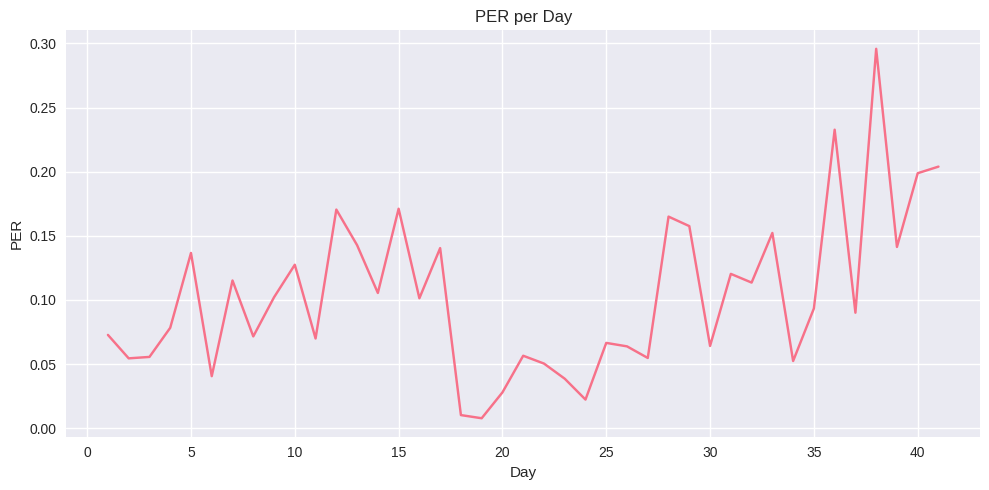

In [13]:
plt.figure(figsize=(10,5))
plt.plot(range(1, len(per_list)+1), per_list)
plt.xlabel("Day")
plt.ylabel("PER")
plt.title("PER per Day")
plt.tight_layout()
plt.savefig(f'./metrics/{MODEL_NAME}/PER_days.png')

# Creating Confusion Matrix from sampled validation batches

In [14]:
import numpy as np
import matplotlib.pyplot as plt

LOGIT_TO_PHONEME = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW',
    'AY', 'B', 'CH', 'D', 'DH', 'EH', 'ER', 'EY', 'F', 'G',
    'HH', 'IH', 'IY', 'JH', 'K', 'L', 'M', 'N', 'NG', 'OW',
    'OY', 'P', 'R', 'S', 'SH', 'T', 'TH', 'UH', 'UW', 'V',
    'W', 'Y', 'Z', 'ZH', ' | ',
]

# create map excluding BLANK
phoneme_map = {i: ph for i, ph in enumerate(LOGIT_TO_PHONEME) if ph != 'BLANK'}
idx_map = {i: new_i for new_i, i in enumerate(phoneme_map.keys())}  # map old idx -> new idx
n_classes = len(phoneme_map)

conf_matrix = np.zeros((n_classes, n_classes), dtype=int)

for batch_idx in range(len(metrics['decoded_seqs'])):
    decoded_batch = metrics['decoded_seqs'][batch_idx]
    true_batch = metrics['true_seq'][batch_idx]
    phone_lens = metrics['phone_seq_lens'][batch_idx]

    for pred_seq, true_seq, seq_len in zip(decoded_batch, true_batch, phone_lens):
        true_seq_trim = true_seq[:seq_len]  # remove padding
        pred_seq_trim = [p for p in pred_seq if p != 0]  # remove blanks

        min_len = min(len(true_seq_trim), len(pred_seq_trim))
        for t, p in zip(true_seq_trim[:min_len], pred_seq_trim[:min_len]):
            if t in idx_map and p in idx_map:  # skip BLANKs
                conf_matrix[idx_map[t], idx_map[p]] += 1

# compute percent accuracy per class
true_counts = conf_matrix.sum(axis=1, keepdims=True)
conf_matrix_perc = conf_matrix / np.maximum(true_counts, 1) * 100

# Plotting Confusion Matrix

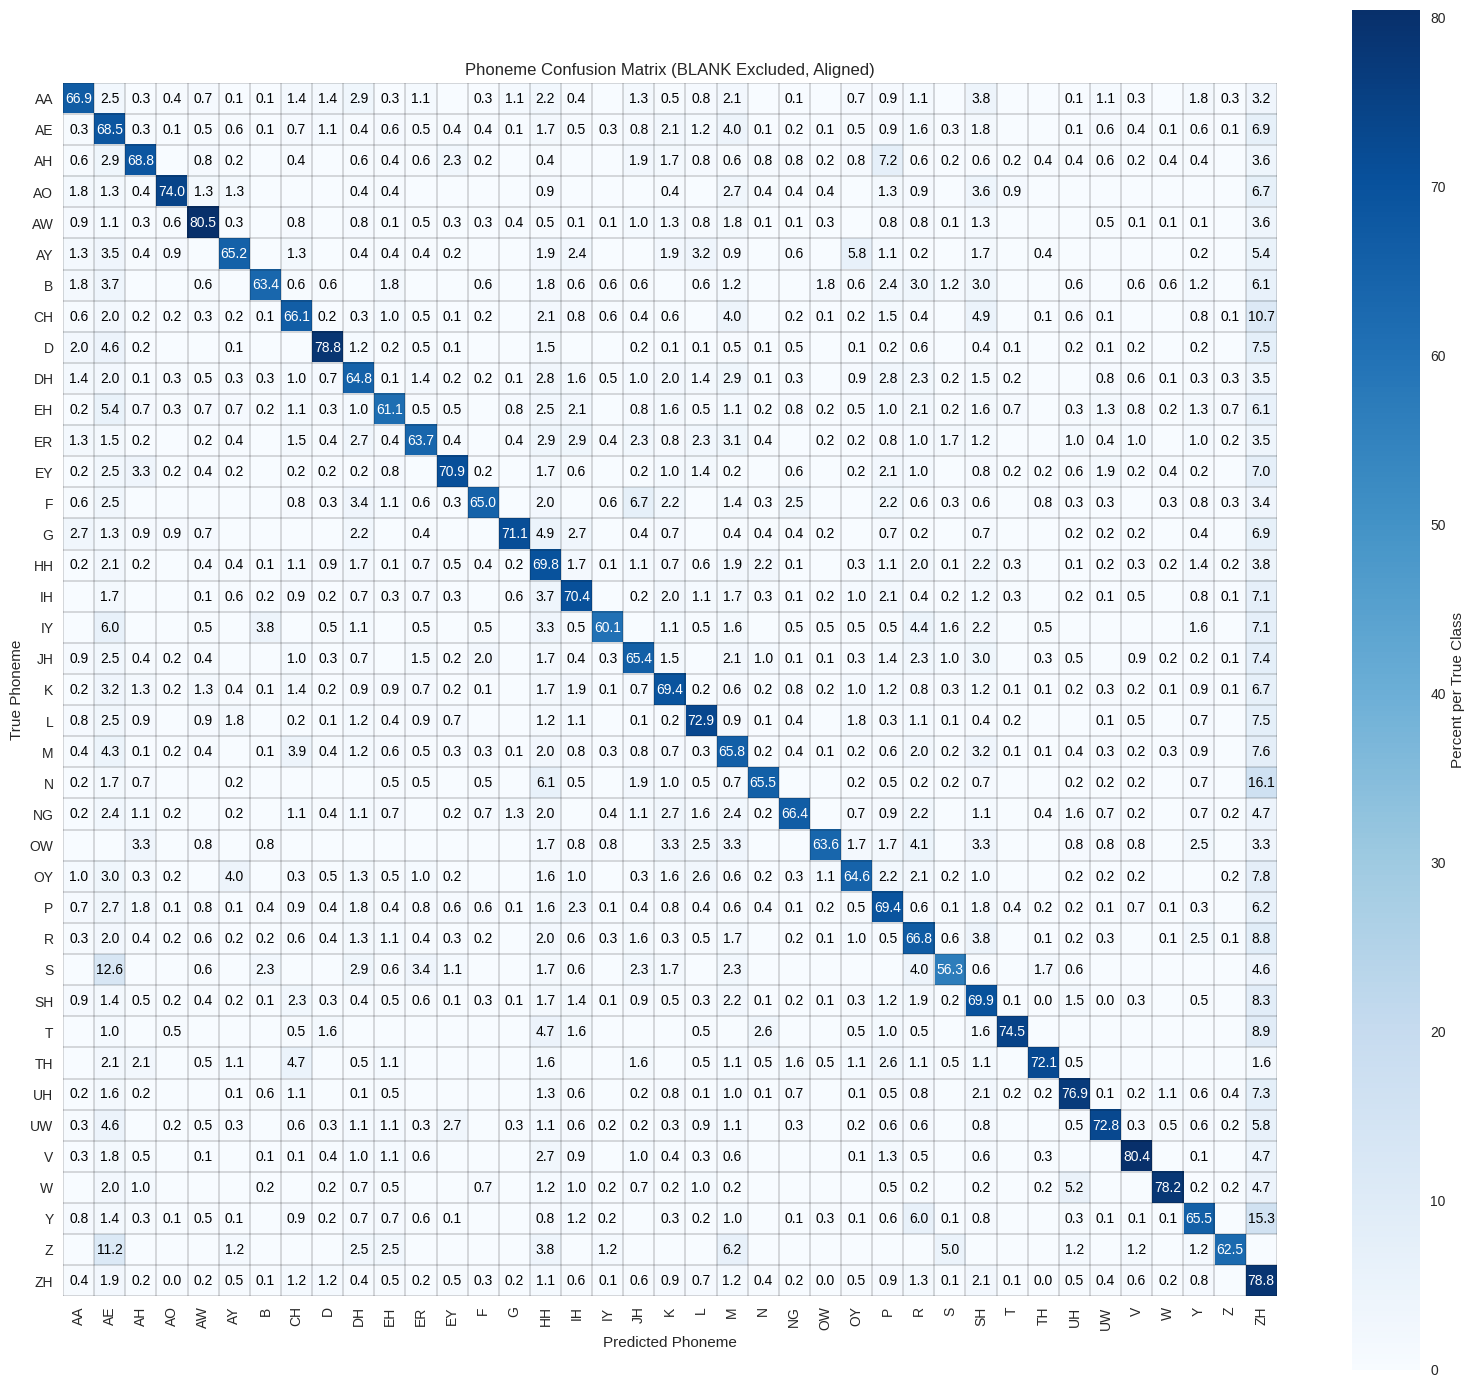

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Slice confusion matrix
conf_matrix_no_blank = conf_matrix[1:, 1:]
n_classes_no_blank = conf_matrix_no_blank.shape[0]

# Labels must match n_classes_no_blank exactly
phoneme_labels = LOGIT_TO_PHONEME[1:1+n_classes_no_blank]  # slice to length 39

# Normalize per true class
true_counts_no_blank = conf_matrix_no_blank.sum(axis=1, keepdims=True)
conf_matrix_perc_no_blank = conf_matrix_no_blank / np.maximum(true_counts_no_blank, 1) * 100

# Plot
fig, ax = plt.subplots(figsize=(16,14))
im = plt.imshow(conf_matrix_perc_no_blank, cmap=plt.cm.Blues, vmin=0, vmax=conf_matrix_perc_no_blank.max())

# Add annotations
for i in range(n_classes_no_blank):
    for j in range(n_classes_no_blank):
        if conf_matrix_perc_no_blank[i,j] > 0:
            plt.text(j, i, f"{conf_matrix_perc_no_blank[i,j]:.1f}",
                     ha="center", va="center",
                     color="white" if conf_matrix_perc_no_blank[i,j]>50 else "black")

# Tick labels
ax.set_xticks(np.arange(n_classes_no_blank))
ax.set_xticklabels(phoneme_labels, rotation=90)
ax.set_yticks(np.arange(n_classes_no_blank))
ax.set_yticklabels(phoneme_labels)

# Turn off gridlines / spines to remove “cross”
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Add thin black borders between cells
ax.set_xticks(np.arange(-0.5, n_classes_no_blank, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_classes_no_blank, 1), minor=True)
ax.grid(which='minor', color='black', linestyle='-', linewidth=0.2)

plt.colorbar(im, label='Percent per True Class')
plt.xlabel("Predicted Phoneme")
plt.ylabel("True Phoneme")
plt.title("Phoneme Confusion Matrix (BLANK Excluded, Aligned)")
plt.tight_layout()
plt.savefig(f'./metrics/{MODEL_NAME}/confusion_matrix.png')
plt.show()

# Confusion Matrix Classification Report

In [16]:
from sklearn.metrics import classification_report

true_labels_flat = []
pred_labels_flat = []

for batch_idx in range(len(metrics['decoded_seqs'])):
    decoded_batch = metrics['decoded_seqs'][batch_idx]
    true_batch = metrics['true_seq'][batch_idx]
    phone_lens = metrics['phone_seq_lens'][batch_idx]

    for pred_seq, true_seq, seq_len in zip(decoded_batch, true_batch, phone_lens):
        true_seq_trim = true_seq[:seq_len]  # remove padding
        pred_seq_trim = [p for p in pred_seq if p != 0]  # remove blanks

        min_len = min(len(true_seq_trim), len(pred_seq_trim))
        for t, p in zip(true_seq_trim[:min_len], pred_seq_trim[:min_len]):
            if t != 0 and p != 0:  # skip BLANK
                true_labels_flat.append(t)
                pred_labels_flat.append(p)

# Map indices to phoneme strings (optional)
phoneme_labels = LOGIT_TO_PHONEME[1:-1]  # exclude BLANK and ' | '

# Generate classification report
report = classification_report(
    true_labels_flat,
    pred_labels_flat,
    labels=list(range(1, len(phoneme_labels)+1)),  # skip BLANK
    target_names=phoneme_labels,
    digits=3
)

print(report)

              precision    recall  f1-score   support

          AA      0.665     0.652     0.658       660
          AE      0.689     0.663     0.676       768
          AH      0.664     0.680     0.672      2690
          AO      0.673     0.669     0.671       541
          AW      0.747     0.737     0.742       224
          AY      0.799     0.798     0.798       805
           B      0.647     0.651     0.649       464
          CH      0.654     0.630     0.642       165
           D      0.656     0.660     0.658      1263
          DH      0.779     0.787     0.783      1061
          EH      0.622     0.647     0.635       864
          ER      0.643     0.607     0.625       614
          EY      0.620     0.635     0.627       521
           F      0.699     0.707     0.703       485
           G      0.671     0.643     0.656       361
          HH      0.825     0.706     0.761       453
          IH      0.680     0.697     0.689      2058
          IY      0.693    

In [17]:
report = classification_report(
    true_labels_flat,
    pred_labels_flat,
    labels=list(range(1, len(phoneme_labels)+1)),  # skip BLANK
    target_names=phoneme_labels,
    digits=4,
    output_dict=True
)

precision_list = [report[name]["precision"] for name in phoneme_labels]
recall_list    = [report[name]["recall"]    for name in phoneme_labels]
f1_score_list  = [report[name]["f1-score"]  for name in phoneme_labels]
support_list   = [report[name]["support"]   for name in phoneme_labels]

metrics_bars.png


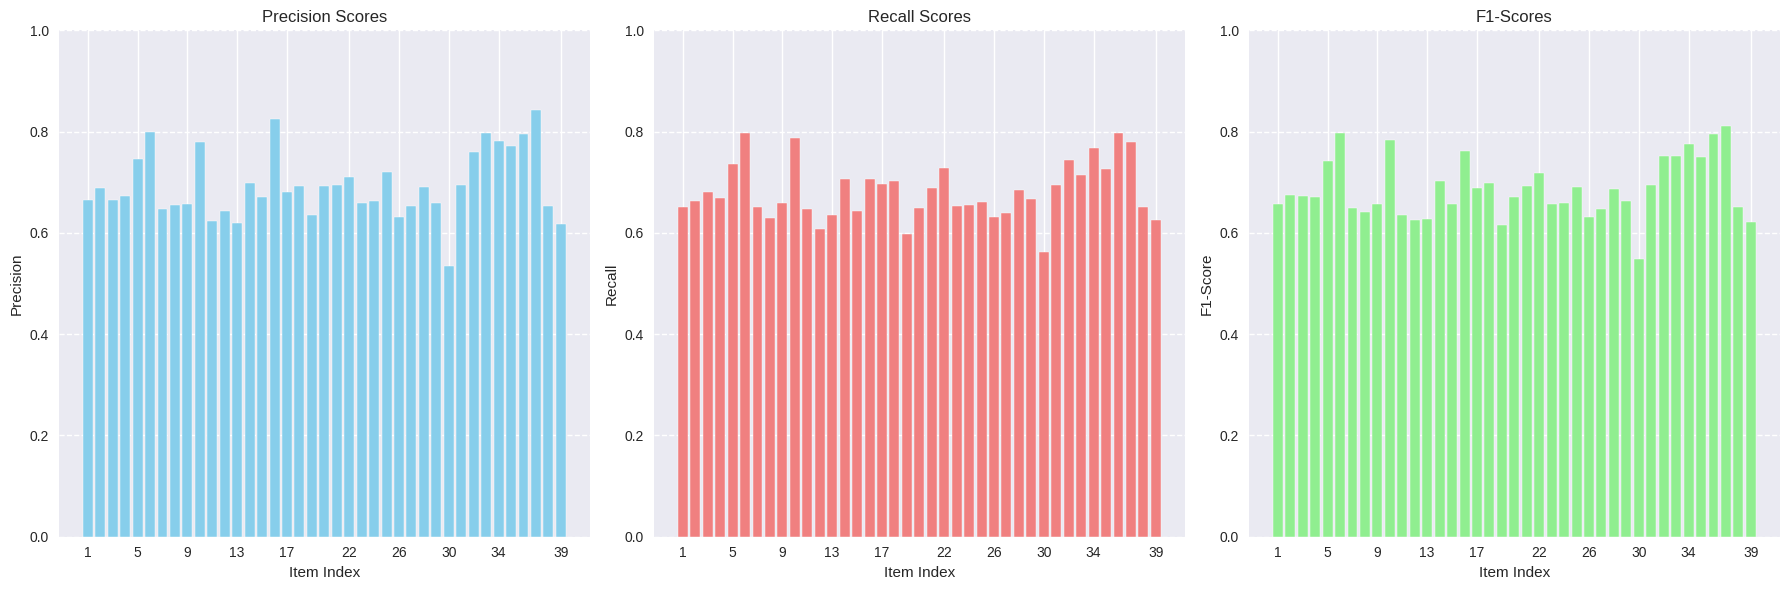

In [18]:
num_items = len(precision_list)
x_index = np.arange(1, num_items + 1)

# Create a figure with 3 subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

# Precision subplot
axes[0].bar(x_index, precision_list, color='skyblue')
axes[0].set_title('Precision Scores')
axes[0].set_xlabel('Item Index')
axes[0].set_ylabel('Precision')
axes[0].grid(axis='y', linestyle='--')
axes[0].set_ylim(0, 1)
axes[0].set_xticks(np.linspace(1, num_items, 10, dtype=int))

# Recall subplot
axes[1].bar(x_index, recall_list, color='lightcoral')
axes[1].set_title('Recall Scores')
axes[1].set_xlabel('Item Index')
axes[1].set_ylabel('Recall')
axes[1].grid(axis='y', linestyle='--')
axes[1].set_ylim(0, 1)
axes[1].set_xticks(np.linspace(1, num_items, 10, dtype=int))

# F1-Score subplot
axes[2].bar(x_index, f1_score_list, color='lightgreen')
axes[2].set_title('F1-Scores')
axes[2].set_xlabel('Item Index')
axes[2].set_ylabel('F1-Score')
axes[2].grid(axis='y', linestyle='--')
axes[2].set_ylim(0, 1)
axes[2].set_xticks(np.linspace(1, num_items, 10, dtype=int))

plt.tight_layout()
plt.savefig(f'./metrics/{MODEL_NAME}/metrics_bars.png')
print('metrics_bars.png')
plt.show()

In [19]:
def get_lowest_k(arr, k):
    """Return (sorted_values, sorted_indices) for the lowest-k entries."""
    k = min(k, len(arr))
    idx = np.argsort(arr)[:k]          # k smallest indices
    vals = arr[idx]                    # corresponding values
    order = np.argsort(vals)           # sort the k items by value
    return vals[order], (idx + 1)[order]   # +1 for 1-indexed class numbers

def get_highest_k(arr, k):
    """Return (sorted_values, sorted_indices) for the highest-k entries."""
    k = min(k, len(arr))
    idx = np.argsort(arr)[-k:]         # k biggest indices
    vals = arr[idx]                    # corresponding values
    order = np.argsort(vals)         # sort the k items by value
    return vals[order], (idx + 1)[order]   # +1 for 1-indexed class numbers

lowest_k_metric_bars.png


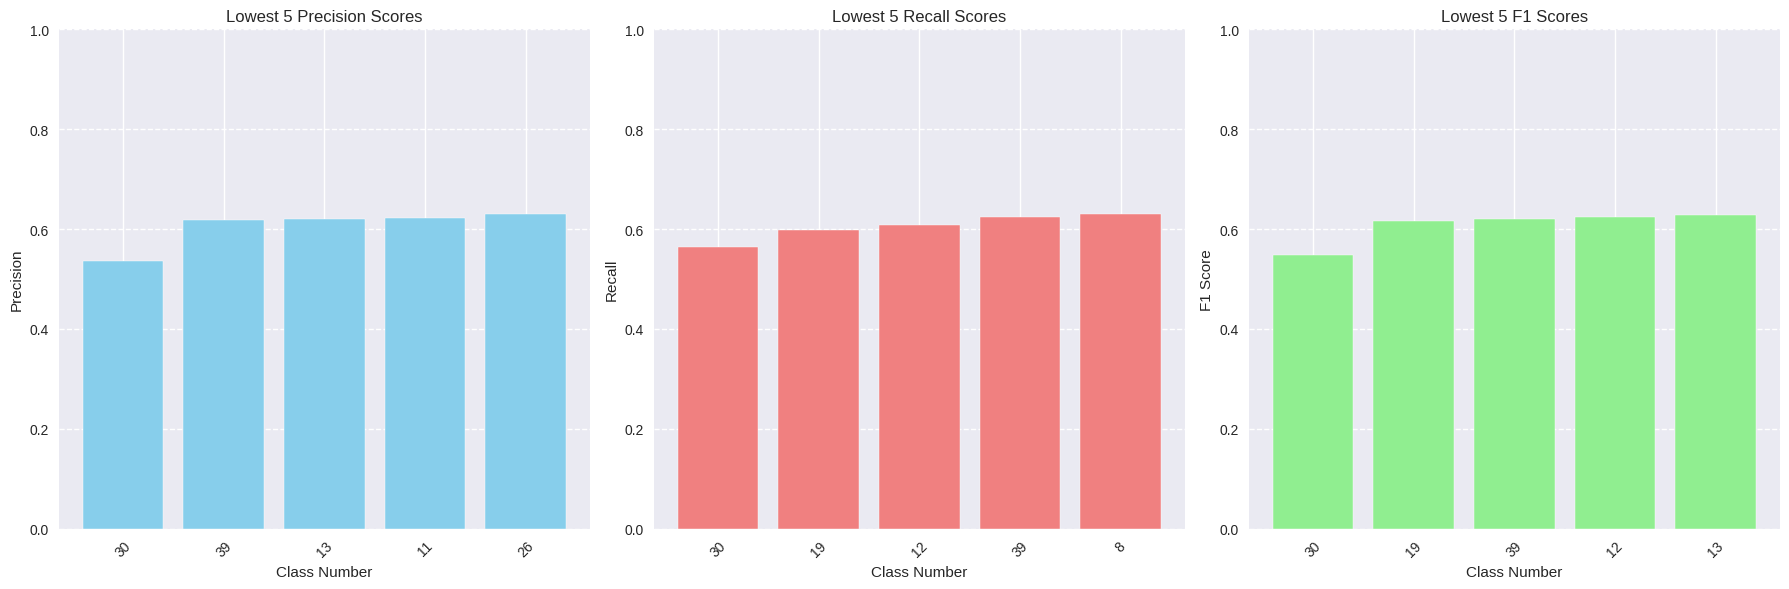

In [20]:
# Convert to numpy arrays
precision_arr = np.array(precision_list)
recall_arr = np.array(recall_list)
f1_arr = np.array(f1_score_list)

# Get sorted lowest-k values + class numbers
prec_vals, prec_classes = get_lowest_k(precision_arr, k)
rec_vals, rec_classes = get_lowest_k(recall_arr, k)
f1_vals, f1_classes = get_lowest_k(f1_arr, k)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision subplot
axes[0].bar(range(k), prec_vals, color='skyblue')
axes[0].set_xticks(range(k))
axes[0].set_xticklabels(prec_classes, rotation=45)
axes[0].set_title(f'Lowest {k} Precision Scores')
axes[0].set_xlabel('Class Number')
axes[0].set_ylabel('Precision')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--')

# Recall subplot
axes[1].bar(range(k), rec_vals, color='lightcoral')
axes[1].set_xticks(range(k))
axes[1].set_xticklabels(rec_classes, rotation=45)
axes[1].set_title(f'Lowest {k} Recall Scores')
axes[1].set_xlabel('Class Number')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--')

# F1 subplot
axes[2].bar(range(k), f1_vals, color='lightgreen')
axes[2].set_xticks(range(k))
axes[2].set_xticklabels(f1_classes, rotation=45)
axes[2].set_title(f'Lowest {k} F1 Scores')
axes[2].set_xlabel('Class Number')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig(f"./metrics/{MODEL_NAME}/lowest_k_metric_bars.png")
print("lowest_k_metric_bars.png")
plt.show()

highest_k_metric_bars.png


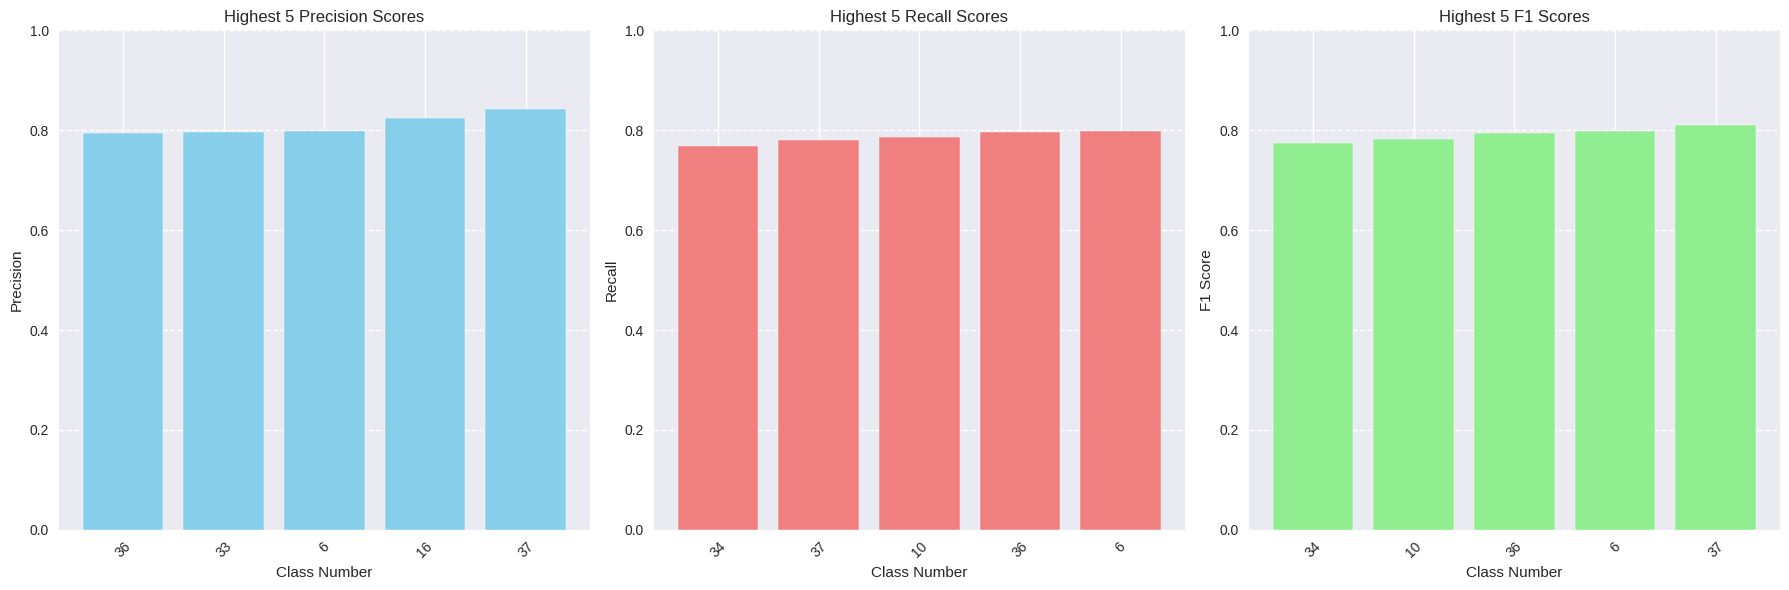

In [21]:
# Get sorted lowest-k values + class numbers
prec_vals, prec_classes = get_highest_k(precision_arr, k)
rec_vals, rec_classes = get_highest_k(recall_arr, k)
f1_vals, f1_classes = get_highest_k(f1_arr, k)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision subplot
axes[0].bar(range(k), prec_vals, color='skyblue')
axes[0].set_xticks(range(k))
axes[0].set_xticklabels(prec_classes, rotation=45)
axes[0].set_title(f'Highest {k} Precision Scores')
axes[0].set_xlabel('Class Number')
axes[0].set_ylabel('Precision')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--')

# Recall subplot
axes[1].bar(range(k), rec_vals, color='lightcoral')
axes[1].set_xticks(range(k))
axes[1].set_xticklabels(rec_classes, rotation=45)
axes[1].set_title(f'Highest {k} Recall Scores')
axes[1].set_xlabel('Class Number')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', linestyle='--')

# F1 subplot
axes[2].bar(range(k), f1_vals, color='lightgreen')
axes[2].set_xticks(range(k))
axes[2].set_xticklabels(f1_classes, rotation=45)
axes[2].set_title(f'Highest {k} F1 Scores')
axes[2].set_xlabel('Class Number')
axes[2].set_ylabel('F1 Score')
axes[2].set_ylim(0, 1)
axes[2].grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig(f"./metrics/{MODEL_NAME}/highest_k_metric_bars.png")
print("highest_k_metric_bars.png")
plt.show()

In [22]:
avg_precision = np.sum(precision_list) / 50
avg_recall = np.sum(recall_list) / 50
avg_f1_score = np.sum(f1_score_list) / 50

print("Average Precision =", avg_precision)
print("Average Recall =", avg_recall)
print("Average F1-Score =", avg_f1_score)

Average Precision = 0.5416205281998036
Average Recall = 0.5318357945286125
Average F1-Score = 0.5364466529241474


# Decoding Phonemes

In [23]:
def decode_phonemes(decoded_seqs, mapping=LOGIT_TO_PHONEME):
    all_sequences = []
    for batch in decoded_seqs:
        batch_seqs = []
        for seq in batch:
            # Map indices to phonemes
            phonemes = [mapping[i] for i in seq]

            # Remove 'BLANK's
            phonemes = [p for p in phonemes if p != 'BLANK']

            # Collapse consecutive ' | '
            collapsed = []
            for p in phonemes:
                if p != ' | ':
                    collapsed.append(p)
                else:
                    if len(collapsed) == 0 or collapsed[-1] != '|':
                        collapsed.append('|')

            # Join as string and strip leading/trailing '|'
            s = ' '.join(collapsed).strip()
            if s.startswith('|'):
                s = s[1:].strip()
            if s.endswith('|'):
                s = s[:-1].strip()

            batch_seqs.append(s)
        all_sequences.append(batch_seqs)
    return all_sequences

# Example usage
readable_seqs = decode_phonemes(metrics['decoded_seqs'])
print(readable_seqs[0][:1])

['Y UW | K AE N | S IY | DH AH | K OW D | AE T | DH IH S | P OY N T | AE Z | W IH L']
